<a href="https://colab.research.google.com/github/ChenHY1217/Projects-In-MLAI/blob/main/ProjectsinMLAIhw5_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNNs, AEs, GANs, Attention Mechanism

## Task 2 - VAE and GAN

### Part 1 - VAE

We use the same image dataset as the last task - GTSRB dataset of traffic signs.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMG_SIZE = 64
BATCH_SIZE = 32

transform_std = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

transform_gan = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset_std = datasets.GTSRB(root='./data', split='train', transform=transform_std, download=True)
train_loader_std = DataLoader(train_dataset_std, batch_size=BATCH_SIZE, shuffle=True)

print(f"Successfully loaded {len(train_dataset_std)} training images.")

100%|██████████| 187M/187M [00:05<00:00, 33.6MB/s]


Successfully loaded 26640 training images.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(ConvVAE, self).__init__()

        # Encoder
        self.enc_conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)

        # Latent space mapping
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        # Decoder
        self.dec_fc = nn.Linear(latent_dim, 128 * 8 * 8)
        self.dec_conv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=0)
        self.dec_conv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=0)
        self.dec_conv3 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1, output_padding=0)

    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = F.relu(self.enc_conv3(x))
        x = torch.flatten(x, start_dim=1)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = F.relu(self.dec_fc(z))
        x = x.view(-1, 128, 8, 8) # Reshape back to feature map
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = torch.sigmoid(self.dec_conv3(x)) # Sigmoid to output pixel values between 0 and 1
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_model = ConvVAE().to(device)

Training VAE

Epoch: 1 Average loss: 311.4061
Epoch: 2 Average loss: 182.9794
Epoch: 3 Average loss: 159.4124
Epoch: 4 Average loss: 148.2723
Epoch: 5 Average loss: 140.7146
Epoch: 6 Average loss: 136.1821
Epoch: 7 Average loss: 132.0100
Epoch: 8 Average loss: 129.0019
Epoch: 9 Average loss: 126.9034
Epoch: 10 Average loss: 124.5828
Epoch: 11 Average loss: 123.1207
Epoch: 12 Average loss: 121.3170
Epoch: 13 Average loss: 120.1580
Epoch: 14 Average loss: 118.9965
Epoch: 15 Average loss: 118.0510
Epoch: 16 Average loss: 117.1464
Epoch: 17 Average loss: 116.4828
Epoch: 18 Average loss: 115.5845
Epoch: 19 Average loss: 114.8889
Epoch: 20 Average loss: 114.4124
Epoch: 21 Average loss: 113.6391
Epoch: 22 Average loss: 113.1668
Epoch: 23 Average loss: 112.7675
Epoch: 24 Average loss: 112.3269
Epoch: 25 Average loss: 111.7853
Epoch: 26 Average loss: 111.4692
Epoch: 27 Average loss: 111.0479
Epoch: 28 Average loss: 110.6151
Epoch: 29 Average loss: 110.6415
Epoch: 30 Average loss: 110.0766


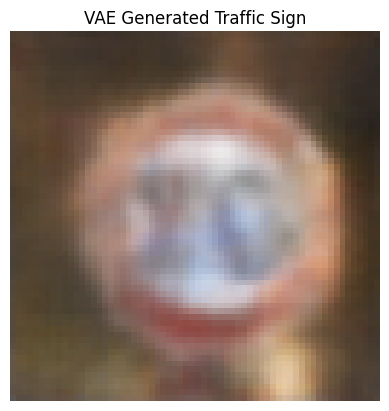

In [ ]:
def vae_loss_function(recon_x, x, mu, logvar):
    # MSE for reconstruction
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

optimizer_vae = optim.Adam(vae_model.parameters(), lr=1e-3)

epochs_vae = 30

for epoch in range(epochs_vae):
    vae_model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader_std):
        data = data.to(device)
        optimizer_vae.zero_grad()

        recon_batch, mu, logvar = vae_model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        train_loss += loss.item()
        optimizer_vae.step()

    print(f'Epoch: {epoch+1} Average loss: {train_loss / len(train_loader_std.dataset):.4f}')

# Generating a new image
vae_model.eval()
with torch.no_grad():
    sample_noise = torch.randn(1, 128).to(device)
    generated_img = vae_model.decode(sample_noise).cpu()
    plt.imshow(generated_img.view(3, 64, 64).permute(1, 2, 0).numpy())
    plt.title("VAE Generated Traffic Sign")
    plt.axis('off')
    plt.show()

### Part 2 - GAN

In [ ]:
train_dataset_gan = datasets.GTSRB(root='./data', split='train', transform=transform_gan, download=True)
train_loader_gan = DataLoader(train_dataset_gan, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
# The latent space size
nz = 100

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is Z (nz x 1 x 1)
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh() # Pushes pixels to [-1, 1]
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is 3 x 64 x 64
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# Initialize networks
netG = Generator().to(device)
netD = Discriminator().to(device)

Train GAN

Epoch [1/50] Loss_D: 1.7797 Loss_G: 1.2108 D(x): 0.2933 D(G(z)): 0.0215 / 0.4373
Epoch [2/50] Loss_D: 0.2937 Loss_G: 4.0960 D(x): 0.9495 D(G(z)): 0.2045 / 0.0377
Epoch [3/50] Loss_D: 0.7930 Loss_G: 1.8038 D(x): 0.7549 D(G(z)): 0.2044 / 0.2009
Epoch [4/50] Loss_D: 0.1381 Loss_G: 4.4920 D(x): 0.9207 D(G(z)): 0.0509 / 0.0215
Epoch [5/50] Loss_D: 0.4095 Loss_G: 2.9865 D(x): 0.7368 D(G(z)): 0.0128 / 0.0920
Epoch [6/50] Loss_D: 0.4828 Loss_G: 4.7495 D(x): 0.6567 D(G(z)): 0.0065 / 0.0248
Epoch [7/50] Loss_D: 0.4182 Loss_G: 2.2190 D(x): 0.7682 D(G(z)): 0.0801 / 0.1374
Epoch [8/50] Loss_D: 0.4529 Loss_G: 7.0602 D(x): 0.9661 D(G(z)): 0.3075 / 0.0083
Epoch [9/50] Loss_D: 0.7860 Loss_G: 1.1086 D(x): 0.5608 D(G(z)): 0.0328 / 0.4093
Epoch [10/50] Loss_D: 1.1957 Loss_G: 1.2493 D(x): 0.3832 D(G(z)): 0.0127 / 0.4297
Epoch [11/50] Loss_D: 0.1660 Loss_G: 3.5506 D(x): 0.9500 D(G(z)): 0.0982 / 0.0519
Epoch [12/50] Loss_D: 0.9411 Loss_G: 8.7366 D(x): 0.8574 D(G(z)): 0.4553 / 0.0021
Epoch [13/50] Loss_D: 0.3

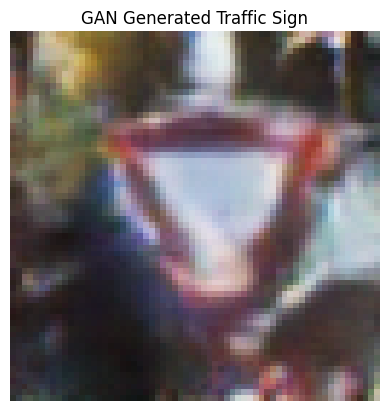

In [ ]:
criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs_gan = 50

for epoch in range(epochs_gan):
    for i, data in enumerate(train_loader_gan, 0):

        # Train Discriminator
        netD.zero_grad()

        # Train with all-real batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1.0, dtype=torch.float, device=device) # Real labels = 1

        output = netD(real_cpu)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Train with all-fake batch
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0) # Fake labels = 0

        output = netD(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        # Train Generator
        netG.zero_grad()
        label.fill_(1.0)

        # Since we just updated D, we pass the fakes through D again
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()

        optimizerG.step()

    print(f'Epoch [{epoch+1}/{epochs_gan}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

# Generate an Image
with torch.no_grad():
    sample_noise = torch.randn(1, nz, 1, 1, device=device)
    fake_img = netG(sample_noise).cpu().detach()

    # reverse the normalization
    fake_img = (fake_img + 1) / 2.0

    plt.imshow(fake_img.view(3, 64, 64).permute(1, 2, 0).numpy())
    plt.title("GAN Generated Traffic Sign")
    plt.axis('off')
    plt.show()

The GAN successfully learned the spatial features of a traffic sign, but eventually suffered from the Discriminator overpowering the Generator.